***Installing Packages***

In [ ]:
!pip install mne

`This installs the MNE package using pip, which is a package manager for Python.`

***Importing Packages***

In [1]:
import numpy as np
import mne
import matplotlib 

`These are the packages being imported. 
numpy is a package for numerical computing in Python, 
mne is the package used for EEG data analysis and matplotlib is a package used for data visualization.`

In [4]:
matplotlib.use('Qt5Agg') 
#For interactive garphs we are using 'Qt5Agg'

``This line sets the backend for matplotlib graphics to Qt5Agg, which allows for interactive plots.``

***Loading data***

In [2]:
# Load MNE sample EEG data
raw = mne.io.read_raw_fif(str(mne.datasets.sample.data_path() / 'MEG' / 'sample' / 'sample_audvis_filt-0-40_raw.fif'), preload=True)

Opening raw data file C:\Users\Manish\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
Reading 0 ... 41699  =      0.000 ...   277.709 secs...


`The line of code reads a raw MEG data file (in FIF format) that comes with the MNE-Python sample dataset.`

`The str() function converts the path of the file to a string, the mne.datasets.sample.data_path() function returns the path to the MNE-Python sample dataset, and / 'MEG' / 'sample' / 'sample_audvis_filt-0-40_raw.fif' specifies the path to the specific raw data file. `

`The preload=True argument specifies that the data should be loaded into memory all at once rather than in chunks. The resulting data is stored in the raw variable.`

Using matplotlib as 2D backend.


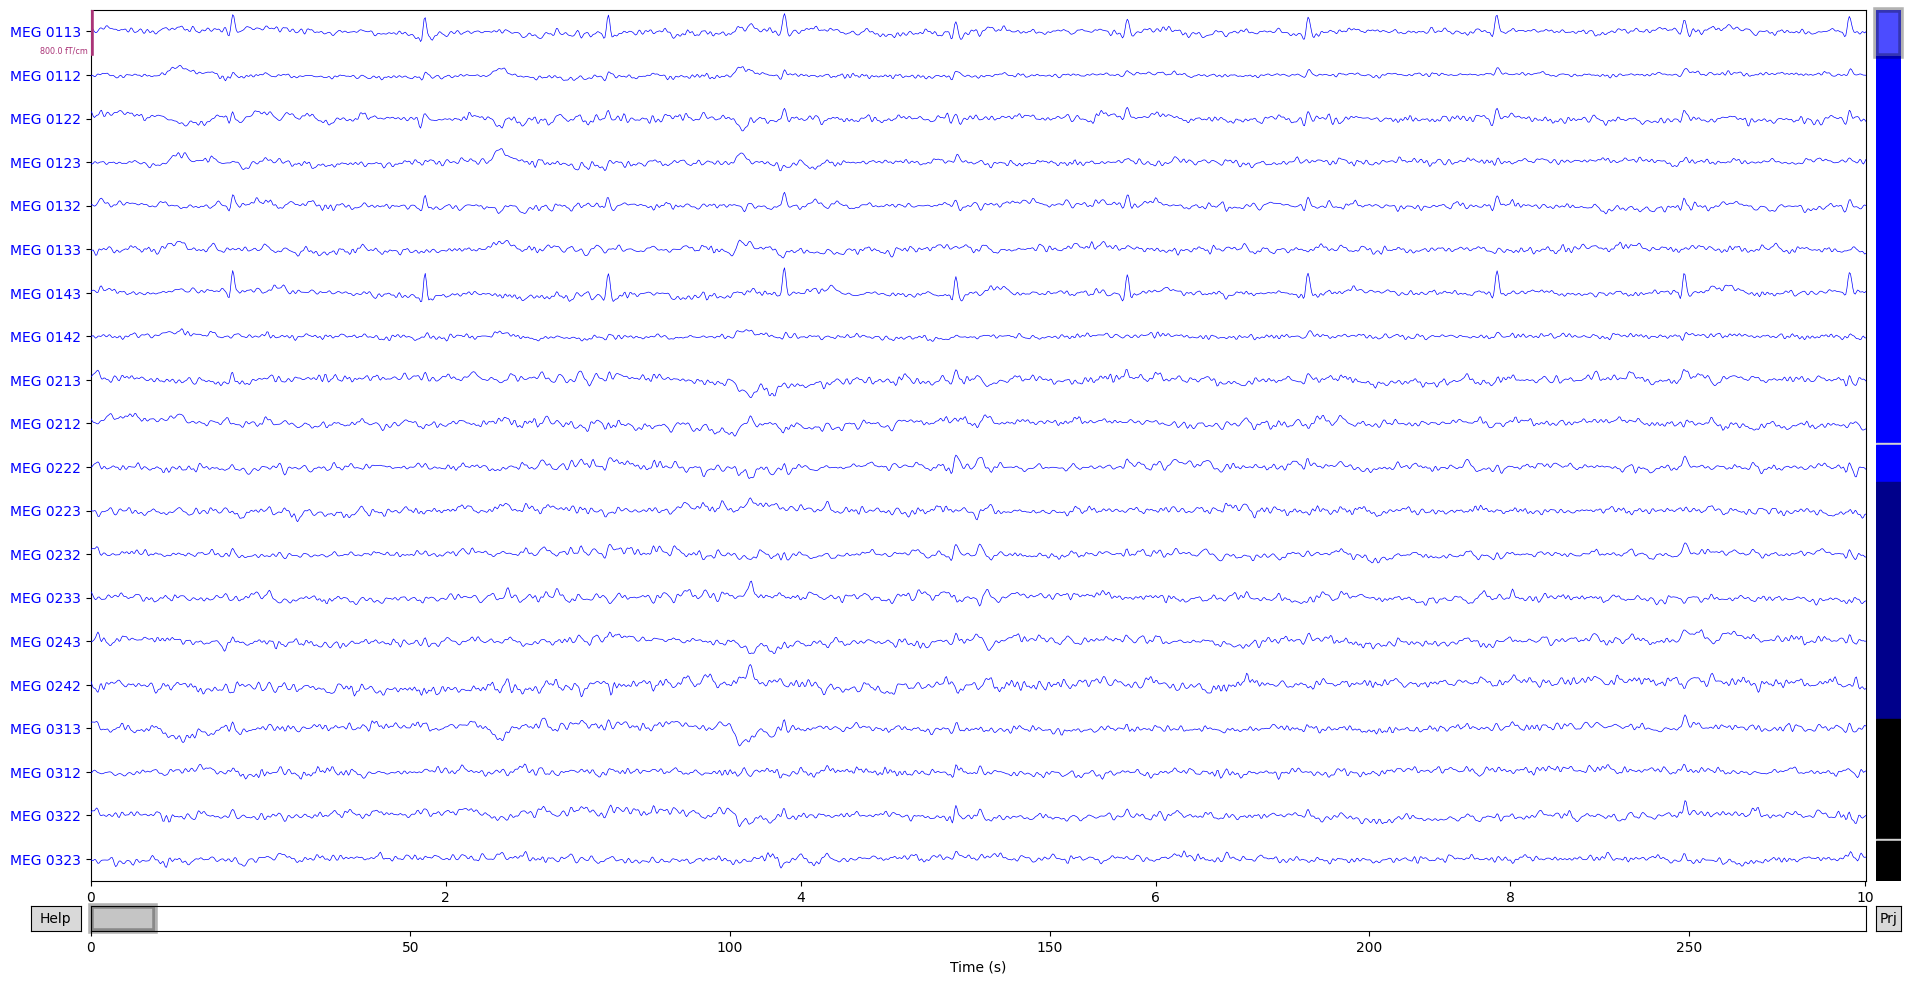

Plot


In [3]:
raw.plot()
print("Plot")

In [6]:
# Remove bad channels
raw.info['bads'] = ['MEG 2443', 'EEG 053']

`We remove the bad channels from the EEG data. Bad channels are those that are not functioning properly or producing noisy data. We can specify the list of bad channels in the raw.info['bads'] attribute.`

***Filtering Data***

In [7]:
# Filter the data
raw.filter(l_freq=1, h_freq=40)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 497 samples (3.310 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done 366 out of 366 | elapsed:    0.7s finished


<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~122.8 MB, data loaded>

`We filter the EEG data to remove any unwanted frequencies. We use the filter function from MNE to apply a bandpass filter to the data with a lower frequency limit of 1 Hz and an upper frequency limit of 40 Hz.`

In [8]:
# Remove eye blinks using ICA
ica = mne.preprocessing.ICA(n_components=20, random_state=42)
ica.fit(raw)
ica.exclude = [0, 1]  # exclude the first two components, which are often related to eye blinks
raw = ica.apply(raw)

Fitting ICA to data using 364 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 7.1s.
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 2 ICA components
    Projecting back using 364 PCA components


`This code is performing Independent Component Analysis (ICA) on the input data raw. ICA is a signal processing technique used to separate mixed signals into their original, independent components. The n_components parameter specifies the number of components to extract from the data, and random_state is used to initialize the random number generator for reproducibility.`

`After fitting the ICA model to the data with ica.fit(raw), the first two components are excluded with ica.exclude = [0, 1]. This is because the first two components often represent eye blink artifacts, which can be removed from the data.`

`Finally, ica.apply(raw) is used to apply the ICA transformation to the input data, effectively removing the unwanted components and producing a new, cleaned version of the data.`

`We re-reference the EEG data to the average reference. This means that we subtract the average of all electrodes from each electrode, which helps to remove any common noise across all electrodes.`

In [9]:
# Epoch the data
events = mne.find_events(raw)

319 events found
Event IDs: [ 1  2  3  4  5 32]


`The line of code events = mne.find_events(raw) uses the MNE-Python library to automatically detect events from the raw data. The function mne.find_events() takes the raw data as input and returns an array of shape (n_events, 3) where each row represents an event and contains information about its onset, duration, and type. This information can then be used for event-related analysis such as epoching the data or averaging event-related potentials.`

In [10]:
event_id = {'left': 1, 'right': 2}

`In this code, we specify that event number 1 is a "left" event and event number 2 is a "right" event using the event_id variable.`

In [11]:
epochs = mne.Epochs(raw, events, event_id, tmin=-0.2, tmax=0.5, baseline=(-0.2, 0), preload=True)

Not setting metadata
145 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 4)
4 projection items activated
Using data from preloaded Raw for 145 events and 106 original time points ...
0 bad epochs dropped


`We set a time window of -0.2 to 0.5 seconds relative to each event using tmin and tmax, which determines how much data to include in each epoch.`

`We also apply baseline correction, which adjusts each epoch's signal by subtracting the mean amplitude of the signal in a pre-defined period before the event (baseline=(-0.2, 0)).`

`preload=True means that the data is loaded into memory all at once for faster processing.`

***Computing the average ERP***

In [12]:
# Compute the average ERP waveform for each condition
evoked_left = epochs['left'].average()

`After epochs are created, the average() method calculates the average response across all epochs for each event type.`

In [13]:
evoked_right = epochs['right'].average()

`In this code, we get the average ERP waveform for the "left" and "right" events and save them in the variables evoked_left and evoked_right.`

***Plotting Topomaps***

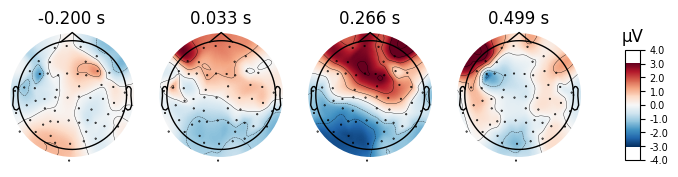


evoked_left


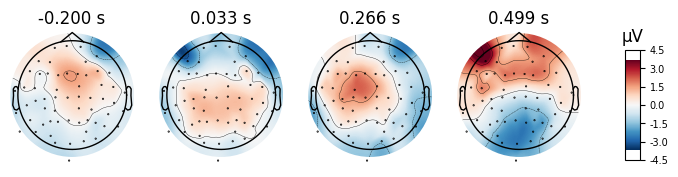


evoked_right


In [17]:
evoked_left.plot_topomap(ch_type='eeg')
print('\nevoked_left')
evoked_right.plot_topomap(ch_type='eeg')
print('\nevoked_right')

`This code is plotting topographic maps of the EEG activity for the two conditions (left and right) using the plot_topomap() method of the Evoked object.`

`evoked_left and evoked_right are Evoked objects that represent the averaged EEG activity for the left and right conditions, respectively. The plot_topomap() method is used to plot the topographic maps of the EEG activity on the scalp electrodes.`

`The ch_type parameter specifies the channel type to use for the topographic maps, which in this case is 'eeg' (electroencephalogram).`

`The print() statements are simply used to print some text to the console to label the plots.`

***Comparing events***

Multiple channel types selected, returning one figure per type.
combining channels using "gfp"
combining channels using "gfp"


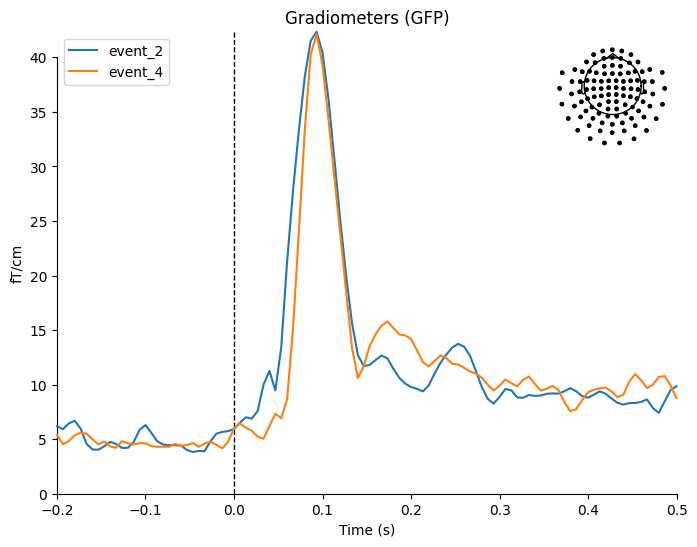

combining channels using "gfp"
combining channels using "gfp"


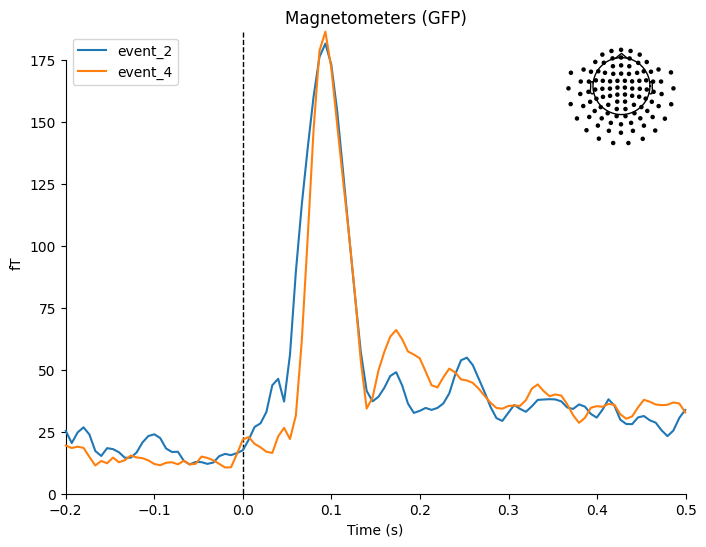

combining channels using "gfp"
combining channels using "gfp"


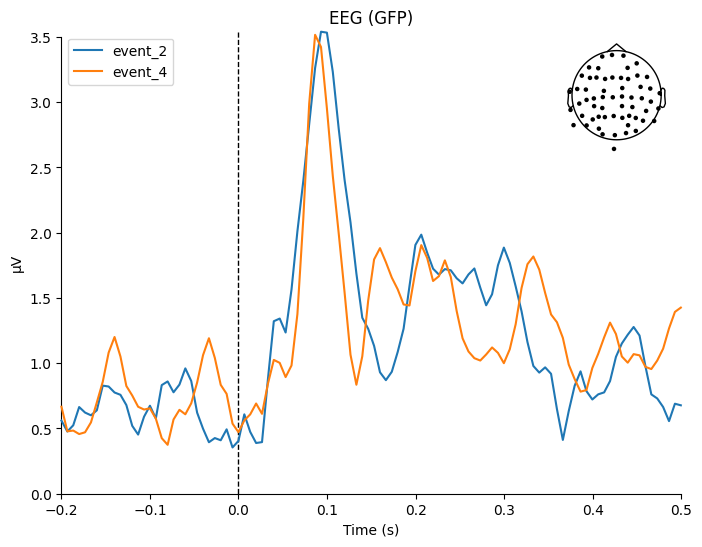

[<Figure size 800x600 with 2 Axes>,
 <Figure size 800x600 with 2 Axes>,
 <Figure size 800x600 with 2 Axes>]

In [23]:
mne.viz.plot_compare_evokeds(dict(event_2=evoked_left, event_4=evoked_right),
                             legend='upper left', show_sensors='upper right')

`The mne.viz.plot_compare_evokeds() function is used to plot and compare multiple evoked responses in the same plot. The function takes a dictionary of evoked objects as input, where the keys are the names of the events and the values are the corresponding evoked objects.`

`In this case, the function is being used to compare the evoked responses for two different events (event_2 and event_4) and plot them in the same figure. The legend parameter specifies where the legend for the plot should be located, and the show_sensors parameter specifies whether to show the sensor locations on the plot.`